In [1]:
from sqlalchemy import create_engine
from snowflake.sqlalchemy import URL
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\snowflake\connector\vendored\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


In [2]:
# Connect to Snowflake
engine = create_engine(URL(
    account = "UHG-UHGDWAAS",
    user = "KHANG.NGUYEN@UHC.COM",
    authenticator = "externalbrowser",
    role = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
    warehouse = "VING_PRD_MNR_HCE_DATAINFRA_WH",
    database = "VING_PRD_TREND_DB",
    schema = "TMP_1M"
))

In [3]:
# hospital_group aggregation — MNR FFS, 2025 only (202501-202512)
# Using ec_ip_dataset_notif (pre-aggregated counts) instead of avtar
df = pd.read_sql("""
    select
        a.hospital_group
        , a.fin_market
        , sum(a.case_count) as case_count_2025
        , sum(a.initial_adr_cnt) as initial_adr_cnt_2025
        , sum(a.persistent_adr_cnt) as persistent_adr_cnt
        , sum(a.p2p_ovrtn_case_cnt) as p2p_ovrtn_cnt
        , sum(a.appeal_ovrtn_case_cnt) as appeal_ovrtn_cnt
        , sum(a.mcr_ovrtn_case_cnt) as mcr_ovrtn_cnt
        , sum(a.md_reviewed_cnt) as md_reviewed_cnt
    from tmp_1m.ec_ip_dataset_notif_06102026_od as a
    where fin_brand = 'M&R'
        and loc_flag = 1
        and ipa_pac_flag in ('IPA', 'MM')
        and mnr_total_ffs_flag = 1
        and hce_admit_month between '202501' and '202512'
        and component = 'Auths'
        and a.hospital_group is not null
    group by 1,2
    having sum(a.case_count) >= 30
""", engine)

print(f"Core (2025): {df.shape}")

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/db05faca-c82a-4b9d-b9c5-0f64b6755421/saml2?SAMLRequest=lVJdb9owFP0rkfec2AnhIxZQsaJuSLRFBaZ2L5NjO2Dh2KntEPj3cwJI3UMr7cGSZZ9zz7n33PHdqZTBkRsrtJqAOEIg4IpqJtRuArabh3AEAuuIYkRqxSfgzC24m44tKWWFZ7Xbqxf%2BXnPrAl9IWdx%2BTEBtFNbECosVKbnFjuL17HGJkwhhYi03zsuBK4VZ4bX2zlUYwqZpoqYXabODCUIIogx6VAv5Bj5IVF9rVEY7TbW8UU6%2Bp08kYojSVsIjvMLqSvwu1GUEX6nkF5DFPzebVbh6Xm9AMLt1d6%2BVrUtu1twcBeXbl%2BXFgPUO6v0u9Ic1hNg%2FexJZpZtCkgOnuqxq52tG%2FgYLzqDUO%2BEntZhPQHUQLFv%2B2C7ZUZ3PWZwg%2Bv6aPQ3W5nWO6nS%2B7r2dHnNyZr23kT5oCoJft1yTNteFtTVfqDZN559QMgjRIIyHm7iPkxFGaTRE6DcI5j5NoYjrmDfLnY%2BoFNRoqwunlRSKdy5ZjvoFoSSko4SEaZ6xMM9oP0TFIM0Hw34%2FTWLYZpaAy97gzoiZ%2Ft80xvAj97qATz6TxXylpaDn4EGbkrjPI4ujuHsRLCw6KOYlEXLGmOHW%2Buik1M294cT5PXem5gBOL6r%2Fbvr0Lw%3D%3D&RelayState=ver%3A3-hint%3A260092117886646-ETMsDgAAAZ7WMlpcABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEFzTc9cqy4l9mZpVC4maIQkAAACQUkqJTjlYXfnR

In [4]:
# member_appeal — 202601+ only (separate time range)
# Using ec_ip_dataset_notif (pre-aggregated counts) instead of avtar
df_ma = pd.read_sql("""
    select
        a.hospital_group
        , a.fin_market
        , sum(a.case_count) as case_count_2026
        , sum(a.initial_adr_cnt) as initial_adr_cnt_2026
        , sum(a.member_appeal_cnt) as member_appeal_cnt
        , sum(a.member_appeal_ovtn_cnt) as member_appeal_ovtn_cnt
    from tmp_1m.ec_ip_dataset_notif_06102026_od as a
    where fin_brand = 'M&R'
        and loc_flag = 1
        and ipa_pac_flag in ('IPA', 'MM')
        and mnr_total_ffs_flag = 1
        and hce_admit_month >= '202601'
        and component = 'Auths'
        and a.hospital_group is not null
    group by 1,2
    having sum(a.initial_adr_cnt) >= 10
""", engine)

engine.dispose()
print(f"Member appeal (202601+): {df_ma.shape}")

Member appeal (202601+): (918, 6)


In [5]:
# merge and compute rates
df = (
    df
    .merge(df_ma, on = ["hospital_group", "fin_market"], how = "left")
    .assign(
        initial_adr_rate_2025 = lambda x: x.initial_adr_cnt_2025 / x.case_count_2025,
        persistent_adr_rate = lambda x: x.persistent_adr_cnt / x.case_count_2025,
        p2p_overturn_rate = lambda x: x.p2p_ovrtn_cnt / x.initial_adr_cnt_2025.replace(0, np.nan),
        appeal_overturn_rate = lambda x: x.appeal_ovrtn_cnt / x.initial_adr_cnt_2025.replace(0, np.nan),
        mcr_overturn_rate = lambda x: x.mcr_ovrtn_cnt / x.initial_adr_cnt_2025.replace(0, np.nan),
        md_review_rate = lambda x: x.md_reviewed_cnt / x.case_count_2025,
        member_appeal_rate = lambda x: x.member_appeal_cnt / x.initial_adr_cnt_2026.replace(0, np.nan),
        initial_adr_rate_2026 = lambda x: x.initial_adr_cnt_2026 / x.case_count_2026,
    )
    .dropna(subset = ["p2p_overturn_rate", "member_appeal_rate"])
)

rate_cols = [
    "initial_adr_rate_2025", "persistent_adr_rate", "p2p_overturn_rate",
    "appeal_overturn_rate", "mcr_overturn_rate", "md_review_rate",
    "member_appeal_rate", "initial_adr_rate_2026"
]
count_cols = [
    "case_count_2025", "initial_adr_cnt_2025", "persistent_adr_cnt", "p2p_ovrtn_cnt",
    "appeal_ovrtn_cnt", "mcr_ovrtn_cnt", "md_reviewed_cnt",
    "case_count_2026", "member_appeal_cnt", "initial_adr_cnt_2026"
]
# Change null to 0
df[rate_cols + count_cols] = df[rate_cols + count_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Shape: {df.shape[0]}")

Shape: 904


In [6]:
# =============================================================================
# DATA PREP: Eligibility filter + Empirical Bayes shrinkage + log-volume features
# =============================================================================
from scipy.stats import median_abs_deviation

# Split a new df out for IF analysis
df_iso = df.copy()
df_iso[count_cols] = df_iso[count_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

# --- Eligibility filter: minimum volume thresholds ---
# Ensures flagged entities have enough sample size to be meaningful
df_iso = (
    df_iso
    .query("case_count_2025 >= 30 and initial_adr_cnt_2025 >= 10 and initial_adr_cnt_2026 >= 10")
    .copy()
)

# --- Empirical Bayes shrinkage (credibility weighting) ---
# adjusted_rate = (observed_num + k * global_rate) / (observed_den + k)
# k=50 pulls small-sample rates toward the population mean to reduce noise
# Hospitals with few cases get pulled more toward the global average
# Hospitals with many cases stay close to their observed rate.
k = 50

# global rates (population-level averages across all eligible hospitals)
gr_initial_adr_25 = df_iso["initial_adr_cnt_2025"].sum() / df_iso["case_count_2025"].sum()
gr_persistent = df_iso["persistent_adr_cnt"].sum() / df_iso["case_count_2025"].sum()
gr_p2p = df_iso["p2p_ovrtn_cnt"].sum() / df_iso["initial_adr_cnt_2025"].sum()
gr_appeal = df_iso["appeal_ovrtn_cnt"].sum() / df_iso["initial_adr_cnt_2025"].sum()
gr_mcr = df_iso["mcr_ovrtn_cnt"].sum() / df_iso["initial_adr_cnt_2025"].sum()
gr_md = df_iso["md_reviewed_cnt"].sum() / df_iso["case_count_2025"].sum()
gr_member_appeal = df_iso["member_appeal_cnt"].sum() / df_iso["initial_adr_cnt_2026"].sum()
gr_initial_adr_26 = df_iso["initial_adr_cnt_2026"].sum() / df_iso["case_count_2026"].sum()

# shrinkage-adjusted rates (overwrite the raw rates with stabilized versions)
df_iso = df_iso.assign(
    initial_adr_rate_2025 = lambda x: (x.initial_adr_cnt_2025 + k * gr_initial_adr_25) / (x.case_count_2025 + k),
    persistent_adr_rate = lambda x: (x.persistent_adr_cnt + k * gr_persistent) / (x.case_count_2025 + k),
    p2p_overturn_rate = lambda x: (x.p2p_ovrtn_cnt + k * gr_p2p) / (x.initial_adr_cnt_2025 + k),
    appeal_overturn_rate = lambda x: (x.appeal_ovrtn_cnt + k * gr_appeal) / (x.initial_adr_cnt_2025 + k),
    mcr_overturn_rate = lambda x: (x.mcr_ovrtn_cnt + k * gr_mcr) / (x.initial_adr_cnt_2025 + k),
    md_review_rate = lambda x: (x.md_reviewed_cnt + k * gr_md) / (x.case_count_2025 + k),
    member_appeal_rate = lambda x: (x.member_appeal_cnt + k * gr_member_appeal) / (x.initial_adr_cnt_2026 + k),
    initial_adr_rate_2026 = lambda x: (x.initial_adr_cnt_2026 + k * gr_initial_adr_26) / (x.case_count_2026 + k),
)

# --- Log-volume features ---
# Gives IF explicit volume signal so it can distinguish
# probable outlier vs "outlier due to small sample"
df_iso = df_iso.assign(
    log_case_count_2025 = lambda x: np.log1p(x.case_count_2025),
    log_initial_adr_cnt_2025 = lambda x: np.log1p(x.initial_adr_cnt_2025),
    log_initial_adr_cnt_2026 = lambda x: np.log1p(x.initial_adr_cnt_2026),
)

# --- Features going into Isolation Forest ---
iso_kpi = [
    "log_case_count_2025", "log_initial_adr_cnt_2025", "log_initial_adr_cnt_2026",
    "initial_adr_rate_2025", "persistent_adr_rate", "p2p_overturn_rate",
    "appeal_overturn_rate", "mcr_overturn_rate", "md_review_rate",
    "member_appeal_rate", "initial_adr_rate_2026"
]

df_iso[iso_kpi] = df_iso[iso_kpi].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"IF-ready: {df_iso.shape[0]} hospitals, {len(iso_kpi)} features")

IF-ready: 893 hospitals, 11 features


In [7]:
# =============================================================================
# ISOLATION FOREST: anomaly detection
# - Distribution-free; contamination=5% sets expected outlier proportion
# - 300 trees for stable scoring
# - StandardScaler normalizes features so no single metric dominates
# =============================================================================
scaler_iso = StandardScaler()
X_iso = scaler_iso.fit_transform(df_iso[iso_kpi])

iso_model = IsolationForest(contamination = 0.05, n_estimators = 300, random_state = 42)
iso_model.fit(X_iso)

df_iso = df_iso.assign(
    anomaly_score = iso_model.decision_function(X_iso),
    anomaly_flag = iso_model.predict(X_iso) == -1,
)
df_iso["anomaly_rank"] = df_iso["anomaly_score"].rank(method = "dense", ascending = True).astype(int)

print(f"Flagged: {df_iso['anomaly_flag'].sum()} / {df_iso.shape[0]} hospitals")

Flagged: 45 / 893 hospitals


In [8]:
# =============================================================================
# MAD Z-SCORES (interpretability layer)
# - MAD z = (x - median) / (MAD * 1.4826)
# - 1.4826 = consistency constant making MAD comparable to SD under normality
# - Used for driver identification, NOT for IF model input
# - More robust to skew than standard z-scores
# =============================================================================
mad_z_cols = [f"{c}_z" for c in iso_kpi]

for col in iso_kpi:
    med = df_iso[col].median()
    mad_scaled = median_abs_deviation(df_iso[col], scale = 1.0) * 1.4826
    df_iso[f"{col}_z"] = (df_iso[col] - med) / mad_scaled if mad_scaled > 0 else 0

print(f"MAD z-scores computed for {len(iso_kpi)} features")

MAD z-scores computed for 11 features


In [9]:
# =============================================================================
# DRIVER IDENTIFICATION
# - For each row: which MAD z-score has the largest absolute value?
# - That metric is the primary "reason" this hospital was flagged.
# =============================================================================
df_iso = df_iso.assign(
    driver = lambda x: x[mad_z_cols].abs().idxmax(axis = 1).str.removesuffix("_z"),
    z_score = lambda x: x[mad_z_cols].apply(lambda r: r[r.abs().idxmax()], axis = 1),
    direction = lambda x: np.where(x.z_score > 0, "high", "low"),
    reason = lambda x: np.where(x.anomaly_flag, x.driver + " (" + x.direction + ")", ""),
)

# --- Driver value, population median, and % deviation ---
# For log-transformed drivers, we report the raw count instead of the log value
# so the output is human-readable (e.g. "case_count = 500" not "log = 6.2")
pop_medians = df_iso[iso_kpi].median()
raw_med_case_count_2025 = df_iso["case_count_2025"].median()
raw_med_initial_adr_2025 = df_iso["initial_adr_cnt_2025"].median()
raw_med_initial_adr_2026 = df_iso["initial_adr_cnt_2026"].median()

df_iso["driver_value"] = np.nan
df_iso["driver_pop_median"] = np.nan
df_iso["driver_dev"] = np.nan

# log drivers → use raw values
mask = df_iso["anomaly_flag"] & (df_iso["driver"] == "log_case_count_2025")
df_iso.loc[mask, "driver_value"] = df_iso.loc[mask, "case_count_2025"]
df_iso.loc[mask, "driver_pop_median"] = raw_med_case_count_2025
df_iso.loc[mask, "driver_dev"] = (df_iso.loc[mask, "case_count_2025"] - raw_med_case_count_2025) / raw_med_case_count_2025

mask = df_iso["anomaly_flag"] & (df_iso["driver"] == "log_initial_adr_cnt_2025")
df_iso.loc[mask, "driver_value"] = df_iso.loc[mask, "initial_adr_cnt_2025"]
df_iso.loc[mask, "driver_pop_median"] = raw_med_initial_adr_2025
df_iso.loc[mask, "driver_dev"] = (df_iso.loc[mask, "initial_adr_cnt_2025"] - raw_med_initial_adr_2025) / raw_med_initial_adr_2025

mask = df_iso["anomaly_flag"] & (df_iso["driver"] == "log_initial_adr_cnt_2026")
df_iso.loc[mask, "driver_value"] = df_iso.loc[mask, "initial_adr_cnt_2026"]
df_iso.loc[mask, "driver_pop_median"] = raw_med_initial_adr_2026
df_iso.loc[mask, "driver_dev"] = (df_iso.loc[mask, "initial_adr_cnt_2026"] - raw_med_initial_adr_2026) / raw_med_initial_adr_2026

# rate drivers → use the rate value directly
for rate_col in rate_cols:
    mask = df_iso["anomaly_flag"] & (df_iso["driver"] == rate_col)
    if mask.any():
        df_iso.loc[mask, "driver_value"] = df_iso.loc[mask, rate_col]
        df_iso.loc[mask, "driver_pop_median"] = pop_medians[rate_col]
        df_iso.loc[mask, "driver_dev"] = (df_iso.loc[mask, rate_col] - pop_medians[rate_col]) / pop_medians[rate_col]

print(f"Drivers assigned for {df_iso['anomaly_flag'].sum()} flagged hospitals")

Drivers assigned for 45 flagged hospitals


In [10]:
# =============================================================================
# OUTPUT ASSEMBLY
# =============================================================================
output_cols = [
    "hospital_group", "fin_market",
    "case_count_2025", "initial_adr_cnt_2025", "case_count_2026", "initial_adr_cnt_2026",
    *iso_kpi, *mad_z_cols,
    "anomaly_score", "anomaly_rank", "anomaly_flag",
    "driver", "z_score", "direction", "reason",
    "driver_value", "driver_pop_median", "driver_dev"
]

df_iso_output = df_iso[output_cols].sort_values("anomaly_score").reset_index(drop = True)

print(f"Model input: {df_iso.shape[0]} entities | Flagged: {df_iso['anomaly_flag'].sum()}")
df_iso_output

Model input: 893 entities | Flagged: 45


,hospital_group,fin_market,case_count_2025,initial_adr_cnt_2025,case_count_2026,initial_adr_cnt_2026,log_case_count_2025,log_initial_adr_cnt_2025,log_initial_adr_cnt_2026,initial_adr_rate_2025,...,anomaly_score,anomaly_rank,anomaly_flag,driver,z_score,direction,reason,driver_value,driver_pop_median,driver_dev
0,ADVOCATE HEALTH & HOSPITALS IL,IL,7402,78,3403.0,34.0,8.909641,4.369448,3.555348,0.012415,...,-0.097607,1,True,md_review_rate,-7.599300,low,md_review_rate (low),0.027049,0.694639,-0.961061
1,Stanford Health Hospital,CA-N,756,62,326.0,35.0,6.629363,4.143135,3.583519,0.094933,...,-0.097139,2,True,appeal_overturn_rate,13.706986,high,appeal_overturn_rate (high),0.056866,0.005197,9.941687
2,Atrium Health System,NC,15875,4912,6070.0,1958.0,9.672564,8.499640,7.580189,0.309357,...,-0.090879,3,True,member_appeal_rate,71.732105,high,member_appeal_rate (high),0.662159,0.020448,31.381973
3,WESTCHESTER GENERAL HOSPITAL,FL,114,79,51.0,42.0,4.744932,4.382027,3.761200,0.570219,...,-0.085564,4,True,member_appeal_rate,6.967181,high,member_appeal_rate (high),0.082776,0.020448,3.048062
4,Froedtert,WI,8277,2264,3625.0,1250.0,9.021357,7.725330,7.131699,0.273630,...,-0.059836,5,True,mcr_overturn_rate,10.115094,high,mcr_overturn_rate (high),0.153582,0.023145,5.635750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,LEE MEMORIAL HEALTH SYSTEM,FL,397,135,314.0,109.0,5.986452,4.912655,4.700480,0.334488,...,0.154384,889,False,persistent_adr_rate,0.599150,high,,NaN,NaN,NaN
889,PRIME HEALTHCARE SVCS-MESQUITE,TX,200,69,104.0,29.0,5.303305,4.248495,3.401197,0.334064,...,0.154479,890,False,md_review_rate,0.587676,high,,NaN,NaN,NaN
890,INSPIRA MEDICAL CENTERS,NJ,385,117,157.0,47.0,5.955837,4.770685,3.871201,0.302336,...,0.156995,891,False,appeal_overturn_rate,-0.792568,low,,NaN,NaN,NaN
891,ST CLAIR HOSPITAL,PA,406,101,149.0,46.0,6.008813,4.624973,3.850148,0.253325,...,0.157094,892,False,appeal_overturn_rate,-0.730457,low,,NaN,NaN,NaN


In [11]:
# =============================================================================
# SHAP: Explain WHY Isolation Forest flagged each hospital
# - Unlike MAD-Z (which just finds the most extreme metric independently),
#   SHAP interrogates the actual IF model to find which features contributed
#   most to each hospital's anomaly score.
# - Catches combination effects (e.g. "high p2p + high appeal together")
#   that MAD-Z would miss.
# =============================================================================
import shap

# Create a SHAP explainer for the Isolation Forest model
# We use the scaled data (X_iso) since that's what the model saw
explainer = shap.TreeExplainer(iso_model)
shap_values = explainer.shap_values(X_iso)

# shap_values is a matrix: (n_hospitals x n_features)
# Each value = how much that feature pushed this hospital's anomaly score
# More negative = more contribution to being flagged as anomaly
print(f"SHAP values shape: {shap_values.shape}")
print(f"Features: {iso_kpi}")

c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (893, 11)
Features: ['log_case_count_2025', 'log_initial_adr_cnt_2025', 'log_initial_adr_cnt_2026', 'initial_adr_rate_2025', 'persistent_adr_rate', 'p2p_overturn_rate', 'appeal_overturn_rate', 'mcr_overturn_rate', 'md_review_rate', 'member_appeal_rate', 'initial_adr_rate_2026']


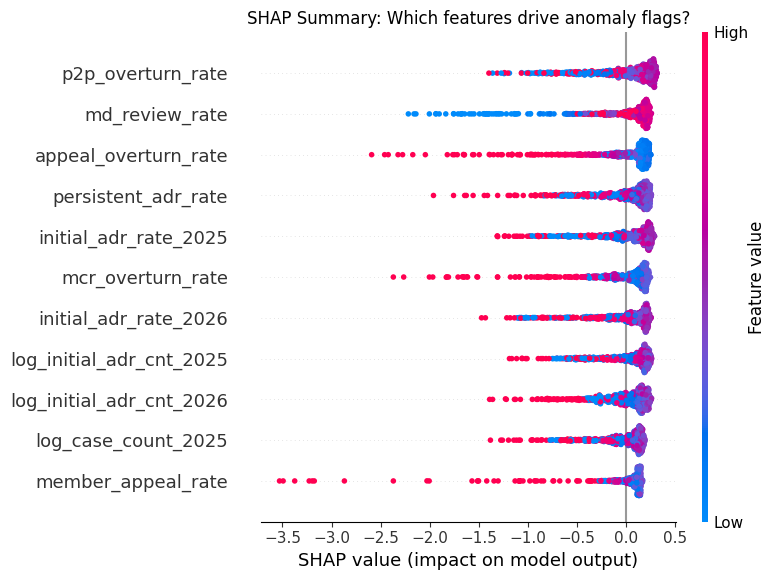

In [12]:
# =============================================================================
# SHAP SUMMARY PLOT: Global feature importance
# - Shows which features matter MOST across all hospitals
# - Each dot = one hospital; x-axis = SHAP value (impact on anomaly score)
# - Color = feature value (red = high, blue = low)
# =============================================================================
shap.summary_plot(shap_values, X_iso, feature_names = iso_kpi, show = False)
plt.title("SHAP Summary: Which features drive anomaly flags?")
plt.tight_layout()
plt.show()

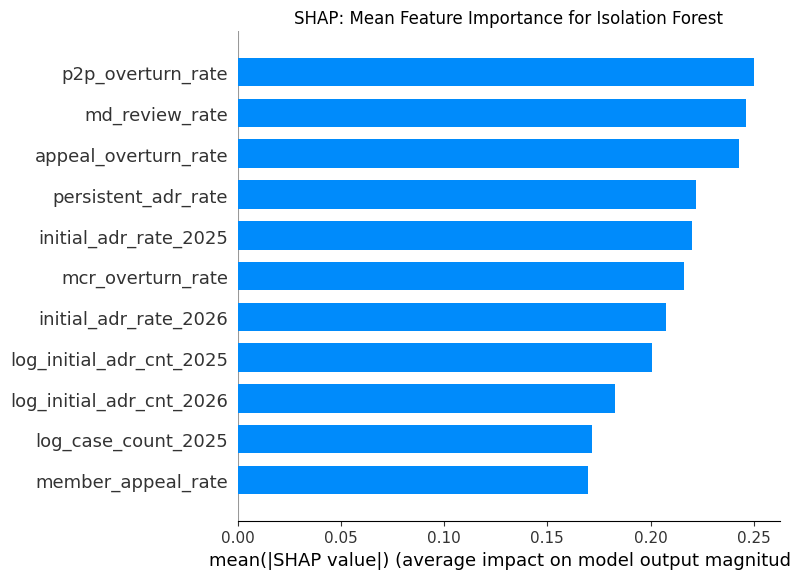

In [13]:
# =============================================================================
# SHAP BAR PLOT: Mean absolute SHAP value per feature
# - Simpler view: just ranks features by overall importance
# - Higher bar = that feature matters more for IF's decisions
# =============================================================================
shap.summary_plot(shap_values, X_iso, feature_names = iso_kpi, plot_type = "bar", show = False)
plt.title("SHAP: Mean Feature Importance for Isolation Forest")
plt.tight_layout()
plt.show()

In [14]:
# =============================================================================
# SHAP FOR FLAGGED HOSPITALS: Per-hospital breakdown
# - For each flagged hospital, shows which features pushed it toward anomaly
# - Compare with MAD-Z driver: do they agree?
# =============================================================================

flagged_idx = df_iso[df_iso["anomaly_flag"]].index
flagged_positions = [df_iso.index.get_loc(idx) for idx in flagged_idx]

shap_flagged = pd.DataFrame(
    shap_values[flagged_positions],
    columns = iso_kpi,
    index = flagged_idx
)

shap_flagged["hospital_group"] = df_iso.loc[flagged_idx, "hospital_group"].values
shap_flagged["fin_market"] = df_iso.loc[flagged_idx, "fin_market"].values
shap_flagged["anomaly_rank"] = df_iso.loc[flagged_idx, "anomaly_rank"].values
shap_flagged["mad_z_driver"] = df_iso.loc[flagged_idx, "driver"].values

shap_flagged["shap_driver"] = shap_flagged[iso_kpi].idxmin(axis = 1)
shap_flagged["shap_driver_value"] = shap_flagged[iso_kpi].min(axis = 1)

shap_flagged["drivers_agree"] = shap_flagged["mad_z_driver"] == shap_flagged["shap_driver"]

print(f"MAD-Z and SHAP drivers agree: {shap_flagged['drivers_agree'].sum()} / {len(shap_flagged)} ({shap_flagged['drivers_agree'].mean():.0%})")
print("="*60)
shap_flagged[["hospital_group", "fin_market", "anomaly_rank", "mad_z_driver", "shap_driver", "shap_driver_value", "drivers_agree"]].sort_values("anomaly_rank")

MAD-Z and SHAP drivers agree: 40 / 45 (89%)


,hospital_group,fin_market,anomaly_rank,mad_z_driver,shap_driver,shap_driver_value,drivers_agree
82,ADVOCATE HEALTH & HOSPITALS IL,IL,1,md_review_rate,md_review_rate,-1.936354,True
695,Stanford Health Hospital,CA-N,2,appeal_overturn_rate,appeal_overturn_rate,-2.322153,True
947,Atrium Health System,NC,3,member_appeal_rate,member_appeal_rate,-3.227966,True
1176,WESTCHESTER GENERAL HOSPITAL,FL,4,member_appeal_rate,persistent_adr_rate,-1.443426,False
1559,Froedtert,WI,5,mcr_overturn_rate,mcr_overturn_rate,-2.002915,True
203,NORTH CAROLINA BAPTIST HOSPITAL SYSTEM,NC,6,member_appeal_rate,member_appeal_rate,-3.375411,True
29,Steward,FL,7,persistent_adr_rate,persistent_adr_rate,-1.756546,True
1615,Nassau Health,NY,8,member_appeal_rate,mcr_overturn_rate,-1.518010,False
864,HEALTH CARE AUTHORITY OF THE CITY OF ANN,AL,9,md_review_rate,md_review_rate,-2.217224,True
1036,Novant Health System,NC,10,p2p_overturn_rate,p2p_overturn_rate,-1.186779,True



ADVOCATE HEALTH & HOSPITALS IL | Rank #1


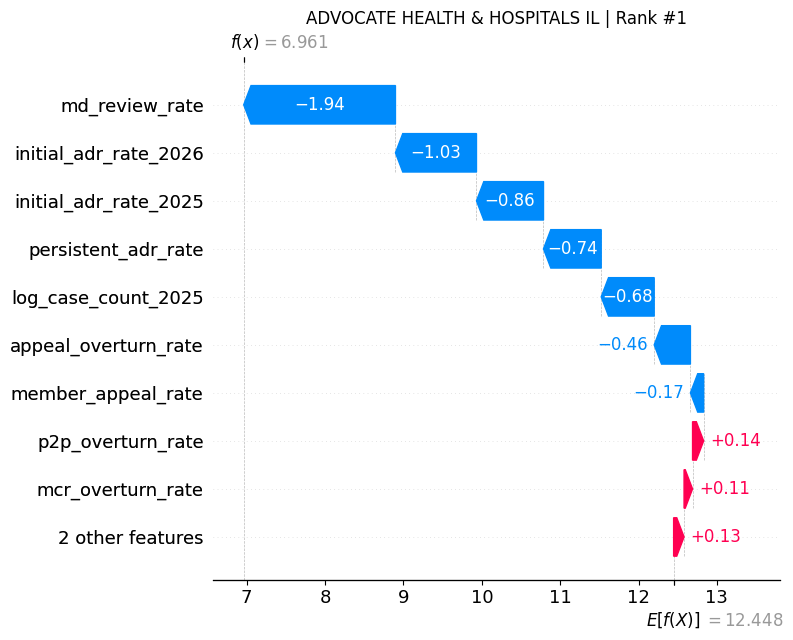


Stanford Health Hospital | Rank #2


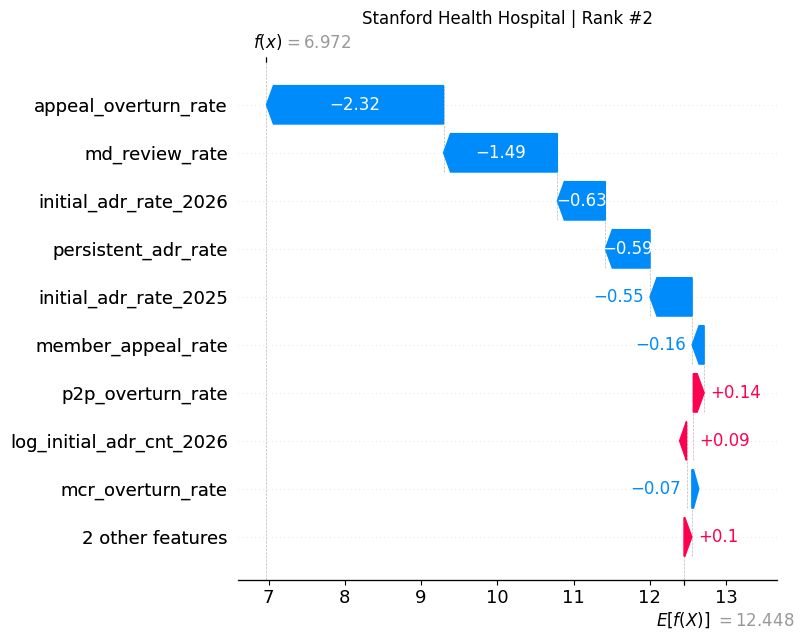


Atrium Health System | Rank #3


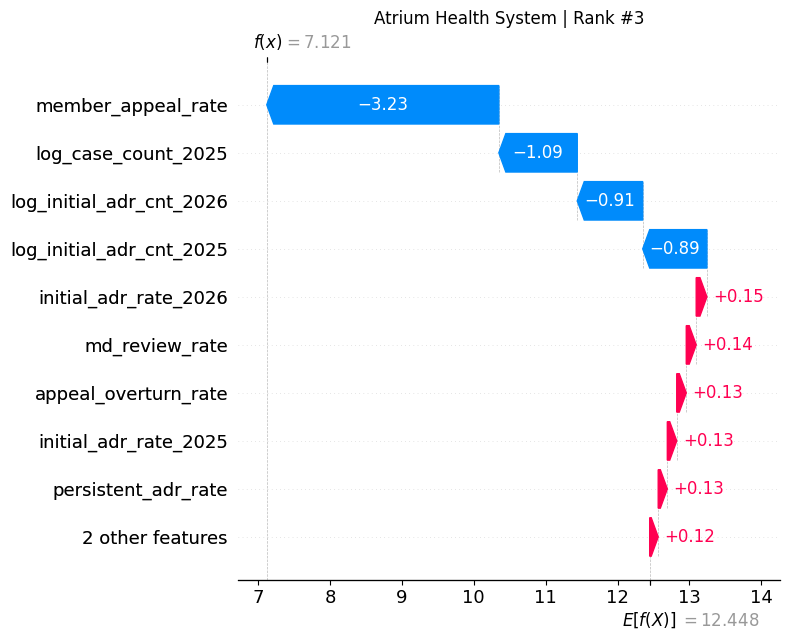


WESTCHESTER GENERAL HOSPITAL | Rank #4


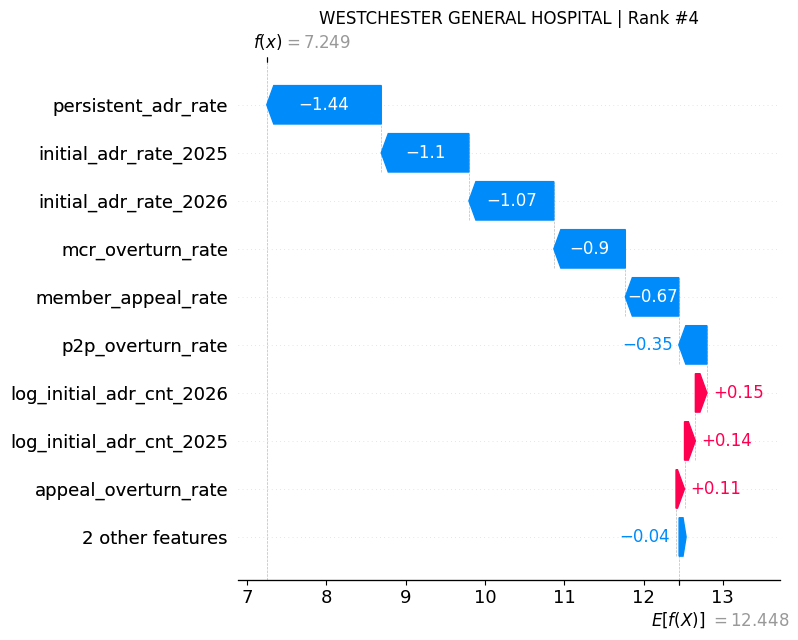


Froedtert | Rank #5


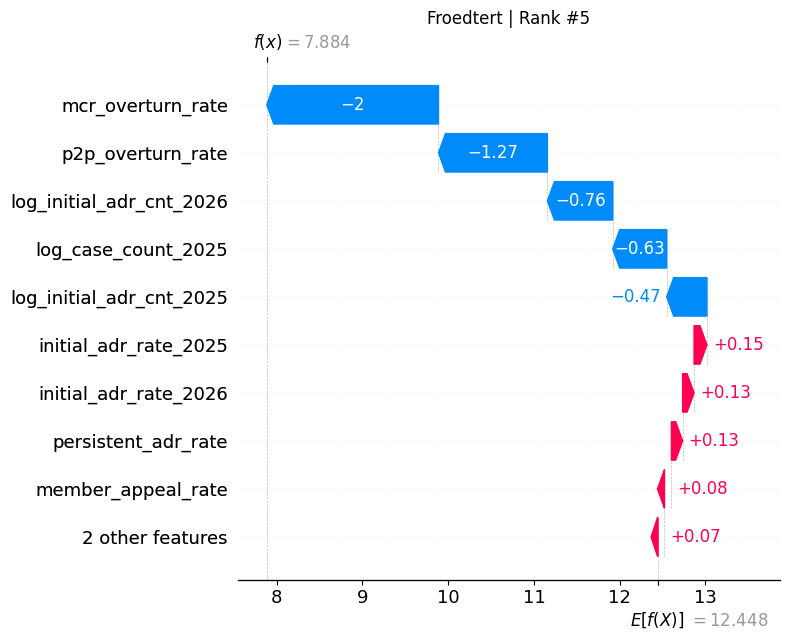

In [15]:
# =============================================================================
# SHAP WATERFALL: Top 5 most anomalous hospitals
# - For each hospital, shows the cumulative effect of each feature
# - Bars going left = pushing toward anomaly
# - Bars going right = pushing toward normal
# =============================================================================

# Get the top 5 most anomalous (by rank)
top5_idx = (
    df_iso[df_iso["anomaly_flag"] & df_iso["hospital_group"].notna()]
    .nsmallest(5, "anomaly_score")
    .index
)

# expected_value can be an array for IF — extract scalar
base_val = float(explainer.expected_value) if np.ndim(explainer.expected_value) == 0 else float(explainer.expected_value[0])

for idx in top5_idx:
    pos = df_iso.index.get_loc(idx)
    hospital_name = df_iso.loc[idx, "hospital_group"]
    rank = int(df_iso.loc[idx, "anomaly_rank"])

    print(f"\n{'='*60}")
    print(f"{hospital_name} | Rank #{rank}")
    print(f"{'='*60}")

    explanation = shap.Explanation(
        values = shap_values[pos],
        base_values = base_val,
        feature_names = iso_kpi
    )
    shap.waterfall_plot(explanation, show = False)
    plt.title(f"{hospital_name[:35]} | Rank #{rank}")
    plt.tight_layout()
    plt.show()

Force plot for: ADVOCATE HEALTH & HOSPITALS IL (Rank #1)


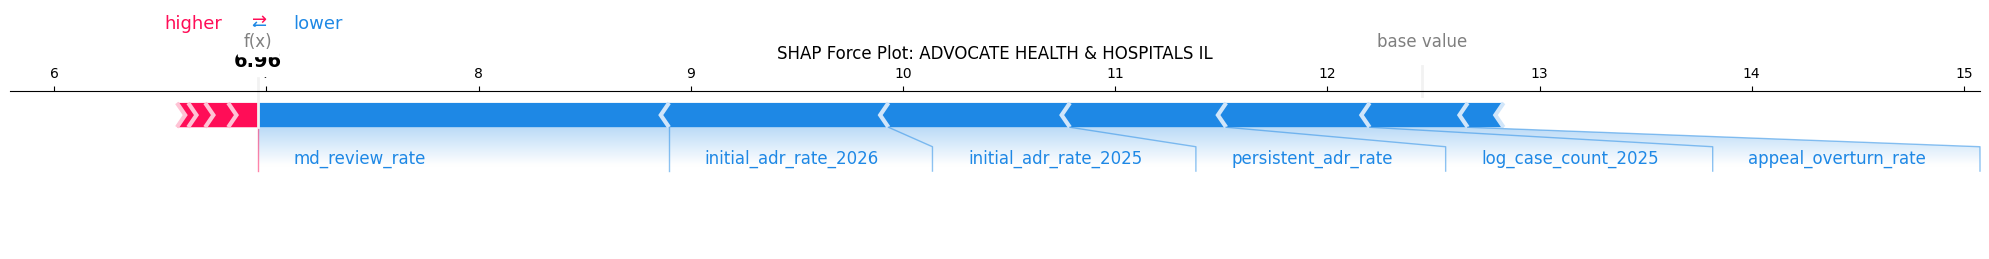

In [16]:
# =============================================================================
# SHAP FORCE PLOT: Interactive view for a single hospital
# - Red features push toward anomaly, blue push toward normal
# - Width of each bar = magnitude of effect
# =============================================================================

# Show force plot for the #1 most anomalous hospital
top1_pos = df_iso.index.get_loc(top5_idx[0])
top1_name = df_iso.loc[top5_idx[0], "hospital_group"]

print(f"Force plot for: {top1_name} (Rank #1)")
shap.force_plot(
    base_val,
    shap_values[top1_pos],
    feature_names = iso_kpi,
    matplotlib = True,
    show = False
)
plt.title(f"SHAP Force Plot: {top1_name[:35]}")
plt.tight_layout()
plt.show()

In [17]:
# =============================================================================
# DISAGREEMENTS: Hospitals where MAD-Z and SHAP picked different drivers
# - Shows both drivers + the SHAP values for all features so you can see
#   what SHAP thinks is actually driving the flag vs what MAD-Z picked
# =============================================================================
disagree = shap_flagged[~shap_flagged["drivers_agree"]].sort_values("anomaly_rank")

print(f"{len(disagree)} hospitals where MAD-Z and SHAP disagree on driver:")
print("="*80)

disagree[["hospital_group", "anomaly_rank", "mad_z_driver", "shap_driver", "shap_driver_value"]]

5 hospitals where MAD-Z and SHAP disagree on driver:


,hospital_group,anomaly_rank,mad_z_driver,shap_driver,shap_driver_value
1176,WESTCHESTER GENERAL HOSPITAL,4,member_appeal_rate,persistent_adr_rate,-1.443426
1615,Nassau Health,8,member_appeal_rate,mcr_overturn_rate,-1.518010
1035,Adventist Health System Florida,21,log_initial_adr_cnt_2026,log_case_count_2025,-1.257843
999,Baptist SFL,22,md_review_rate,log_case_count_2025,-0.777816
1020,PIH Hospital,27,member_appeal_rate,persistent_adr_rate,-1.131922


In [18]:
# Full SHAP breakdown for disagreement hospitals
# Shows all feature contributions so you can see WHY they disagree
disagree[[
    "hospital_group", "anomaly_rank", "mad_z_driver", "shap_driver",
    *iso_kpi
]].style.background_gradient(subset = iso_kpi, cmap = "RdBu", axis = 1)

,hospital_group,anomaly_rank,mad_z_driver,shap_driver,log_case_count_2025,log_initial_adr_cnt_2025,log_initial_adr_cnt_2026,initial_adr_rate_2025,persistent_adr_rate,p2p_overturn_rate,appeal_overturn_rate,mcr_overturn_rate,md_review_rate,member_appeal_rate,initial_adr_rate_2026
1176,WESTCHESTER GENERAL HOSPITAL,4,member_appeal_rate,persistent_adr_rate,-0.097953,0.136860,0.145930,-1.104832,-1.443426,-0.354684,0.106928,-0.901472,0.059029,-0.674042,-1.070786
1615,Nassau Health,8,member_appeal_rate,mcr_overturn_rate,-0.035093,0.128873,0.069973,-0.838710,-0.427432,-0.367820,0.124567,-1.518010,0.173256,-1.501359,-0.157956
1035,Adventist Health System Florida,21,log_initial_adr_cnt_2026,log_case_count_2025,-1.257843,-1.163071,-1.124503,-0.139226,-0.156095,0.117557,0.134505,-0.208563,0.121128,-0.029970,0.001305
999,Baptist SFL,22,md_review_rate,log_case_count_2025,-0.777816,-0.519793,-0.696478,-0.117693,-0.178658,-0.041324,-0.029064,-0.192544,-0.772661,0.048973,-0.398733
1020,PIH Hospital,27,member_appeal_rate,persistent_adr_rate,0.090651,0.180171,0.124547,-0.566854,-1.131922,-1.015749,-0.083156,-0.781520,0.168041,-0.346866,-0.102603


In [19]:
# =============================================================================
# WRITE FLAGGED HOSPITALS TO SNOWFLAKE
# =============================================================================
from sqlalchemy import create_engine
from snowflake.sqlalchemy import URL

engine_write = create_engine(URL(
    account = "UHG-UHGDWAAS",
    user = "KHANG.NGUYEN@UHC.COM",
    authenticator = "externalbrowser",
    role = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
    warehouse = "VING_PRD_MNR_HCE_DATAINFRA_WH",
    database = "VING_PRD_TREND_DB",
    schema = "TMP_1M"
))

flagged = df_iso_output[df_iso_output["anomaly_flag"] == True].copy()
flagged["mad_z_driver"] = flagged["driver"]

shap_lookup = shap_flagged[["hospital_group", "fin_market", "shap_driver"]].reset_index(drop = True)
flagged = flagged.merge(
    shap_lookup,
    on = ["hospital_group", "fin_market"],
    how = "left"
)

flagged.columns = [c.upper() for c in flagged.columns]

flagged.to_sql(
    "kn_loc_if_outlier_hospitals_mnr",
    engine_write,
    schema = "TMP_1M",
    if_exists = "replace",
    index = False
)

engine_write.dispose()
print(f"Wrote {len(flagged)} flagged hospitals to TMP_1M.KN_LOC_IF_OUTLIER_HOSPITALS_MNR")
print(f"Columns: HOSPITAL_GROUP, FIN_MARKET, MAD_Z_DRIVER, SHAP_DRIVER")

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/db05faca-c82a-4b9d-b9c5-0f64b6755421/saml2?SAMLRequest=lVJdb9owFP0rkfecxDHhywIqWtaWru0QhE7by%2BQkDng4dubrNO1%2B%2FZwAUvfQSnuwZNnn3HPuPXdy8VJK75kbEFpNURRg5HGV6Vyo3RRtk2t%2FhDywTOVMasWn6JUDuphNgJWyovPa7tWa%2F645WM8VUkDbjymqjaKagQCqWMmB2oxu5g%2F3lASYMgBurJNDJ0oOwmntra1oGDZNEzS9QJtdSDDGIR6HDtVCPqE3EtXHGpXRVmdanikvrqd3JKIQx62EQziF1Yl4KdRxBB%2BppEcQ0NskWfmrr5sEefNzd1daQV1ys%2BHmWWR8u74%2FGgDnoN7vfHfyhjH4uWcBKN0Ukh14psuqtq5m4G5hwfNQ6p1wk1oupqg6iHy8wN%2Blvb1LD72mfiL8ruyt%2FzCwW5HGm5tDcrkl33493nz5%2FBBnyHs650raXJcANV%2BqNk3rnjAZ%2BHjgR8Mk6lMyoiQO4t7wB%2FIWLk2hmO2YZ8udj6AUmdGgC6uVFIp3LvMU9wuWMT8bEebH6Tj303HW93ExiNPBsN%2BPSRS2mRF03BvaGTGz%2F5vGJHzLPS3go8tkuVhpKbJX71qbktn3I4uCqHsRuV90UMpLJuQ8zw0HcNFJqZsrw5l1e25NzVE4O6r%2Bu%2Bmzvw%3D%3D&RelayState=ver%3A3-hint%3A260092117886646-ETMsDgAAAZ7WMqd1ABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEFBVl0aehK27mZkvK9fDD0QAAACQoq

In [20]:
pop_medians_iso = df_iso[iso_kpi].median()

comparison = shap_flagged[["hospital_group", "fin_market", "anomaly_rank", "mad_z_driver", "shap_driver", "drivers_agree"]].copy()

comparison["mad_z_driver_val"] = comparison.apply(
    lambda r: df_iso.loc[df_iso["hospital_group"] == r["hospital_group"], r["mad_z_driver"]].values[0]
    if r["mad_z_driver"] in iso_kpi else np.nan, axis = 1
)
comparison["mad_z_pop_median"] = comparison["mad_z_driver"].map(pop_medians_iso)

comparison["shap_driver_val"] = comparison.apply(
    lambda r: df_iso.loc[df_iso["hospital_group"] == r["hospital_group"], r["shap_driver"]].values[0]
    if r["shap_driver"] in iso_kpi else np.nan, axis = 1
)
comparison["shap_pop_median"] = comparison["shap_driver"].map(pop_medians_iso)

comparison.sort_values("anomaly_rank")

,hospital_group,fin_market,anomaly_rank,mad_z_driver,shap_driver,drivers_agree,mad_z_driver_val,mad_z_pop_median,shap_driver_val,shap_pop_median
82,ADVOCATE HEALTH & HOSPITALS IL,IL,1,md_review_rate,md_review_rate,True,0.027049,0.694639,0.027049,0.694639
695,Stanford Health Hospital,CA-N,2,appeal_overturn_rate,appeal_overturn_rate,True,0.056866,0.005197,0.056866,0.005197
947,Atrium Health System,NC,3,member_appeal_rate,member_appeal_rate,True,0.407621,0.020448,0.407621,0.020448
1176,WESTCHESTER GENERAL HOSPITAL,FL,4,member_appeal_rate,persistent_adr_rate,False,0.082776,0.020448,0.376035,0.150968
1559,Froedtert,WI,5,mcr_overturn_rate,mcr_overturn_rate,True,0.153582,0.023145,0.153582,0.023145
203,NORTH CAROLINA BAPTIST HOSPITAL SYSTEM,NC,6,member_appeal_rate,member_appeal_rate,True,0.623431,0.020448,0.623431,0.020448
29,Steward,FL,7,persistent_adr_rate,persistent_adr_rate,True,0.385750,0.150968,0.385750,0.150968
1615,Nassau Health,NY,8,member_appeal_rate,mcr_overturn_rate,False,0.179150,0.020448,0.099109,0.023145
864,HEALTH CARE AUTHORITY OF THE CITY OF ANN,AL,9,md_review_rate,md_review_rate,True,0.095128,0.694639,0.095128,0.694639
1036,Novant Health System,NC,10,p2p_overturn_rate,p2p_overturn_rate,True,0.069530,0.374868,0.069530,0.374868
